Image dimensions: (512, 512)


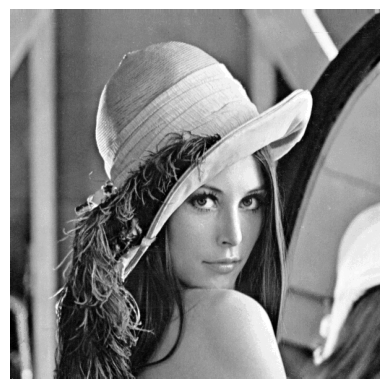

In [1]:
import cv2
import numpy as np
import matplotlib.pyplot as plt

img = cv2.imread('data/lenna.png', cv2.IMREAD_GRAYSCALE)

print(f"Image dimensions: {img.shape}")

plt.imshow(img, cmap='gray')
plt.axis('off')
plt.show()

In [2]:
def block_divide(img, block_size):
    h, w = img.shape
    blocks = [img[i:i+block_size, j:j+block_size] 
              for i in range(0, h, block_size) 
              for j in range(0, w, block_size)]
    return np.array(blocks)

blocks_8x8 = block_divide(img, 8)

print(f"Number of 8x8 blocks: {len(blocks_8x8)}")

Number of 8x8 blocks: 4096


In [3]:
def dct_1d(N):
    dct_mat = np.zeros((N, N))
    for k in range(N):
        for n in range(N):
            if k == 0:
                dct_mat[k, n] = np.sqrt(1 / N)
            else:
                dct_mat[k, n] = np.sqrt(2 / N) * np.cos(np.pi * (2 * n + 1) * k / (2 * N))
    return dct_mat

def dct2_basis(B):
    return np.kron(dct_1d(B), dct_1d(B))

D = dct2_basis(8)

In [4]:
def preprocess_blocks(blocks):
    return blocks.astype(np.float32) - 128

def dct_transform(blocks, D):
    return np.array([D @ block.flatten() for block in blocks])

blocks_preprocessed = preprocess_blocks(blocks_8x8)
blocks_dct = dct_transform(blocks_preprocessed, D)

In [5]:
Q = np.array([
    [16, 11, 10, 16, 24, 40, 51, 61],
    [12, 12, 14, 19, 26, 58, 60, 55],
    [14, 13, 16, 24, 40, 57, 69, 56],
    [14, 17, 22, 29, 51, 87, 80, 62],
    [18, 22, 37, 56, 68, 109, 103, 77],
    [24, 35, 55, 64, 81, 104, 113, 92],
    [49, 64, 78, 87, 103, 121, 120, 101],
    [72, 92, 95, 98, 112, 100, 103, 99]
])

In [6]:
def quantize_dct(blocks_dct, Q):
    return np.round(blocks_dct.reshape(-1, 8, 8) / Q)

blocks_quantized = quantize_dct(blocks_dct, Q)

In [7]:
def dequantize_dct(blocks_quantized, Q):
    return blocks_quantized * Q

blocks_dequantized = dequantize_dct(blocks_quantized, Q)

In [8]:
from scipy.fftpack import idct

def dct_transform(blocks, D):
    return np.array([D @ block.flatten(order='F') for block in blocks])

def idct_transform(blocks_dct, D):
    return np.array([
        (D.T @ block.flatten(order='F')).reshape(8, 8, order='F')
        for block in blocks_dct
    ])

blocks_reconstructed = idct_transform(blocks_dequantized, D)

In [9]:
def postprocess_blocks(blocks):
    return np.clip(blocks + 128, 0, 255)

blocks_reconstructed = postprocess_blocks(blocks_reconstructed)

In [14]:
def reconstruct_image(blocks, block_size, img_shape):
    h, w = img_shape
    img_reconstructed = np.zeros((h, w))
    index = 0
    for i in range(0, h, block_size):
        for j in range(0, w, block_size):
            img_reconstructed[i:i+block_size, j:j+block_size] = blocks[index].reshape(8, 8)
            index += 1
    return img_reconstructed

reconstructed_img = reconstruct_image(blocks_reconstructed, 8, img.shape)

In [15]:
from skimage.metrics import peak_signal_noise_ratio as psnr, structural_similarity as ssim

psnr_value = psnr(img, reconstructed_img, data_range=255)
ssim_value = ssim(img, reconstructed_img, data_range=255)

print(f"PSNR: {psnr_value:.2f}")
print(f"SSIM: {ssim_value:.4f}")

PSNR: 34.92
SSIM: 0.9039


In [16]:
original_size = img.size
compressed_size = blocks_quantized.size

print(f"Original Size: {original_size} pixels")
print(f"Compressed Size: {compressed_size} values")
print(f"Compression Ratio: {original_size / compressed_size:.2f}")

Original Size: 262144 pixels
Compressed Size: 262144 values
Compression Ratio: 1.00


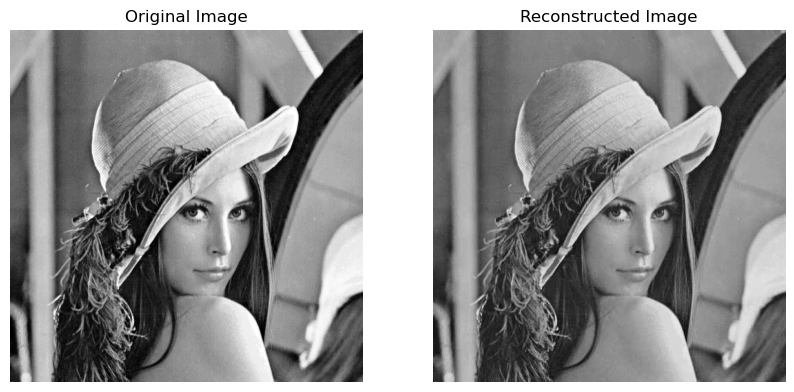

In [17]:
plt.figure(figsize=(10, 5))

plt.subplot(1, 2, 1)
plt.imshow(img, cmap='gray')
plt.axis('off')
plt.title("Original Image")

plt.subplot(1, 2, 2)
plt.imshow(reconstructed_img, cmap='gray')
plt.axis('off')
plt.title("Reconstructed Image")

plt.show()

Mean Absolute Error (MAE): 3.3731
Max Difference: 39.9502


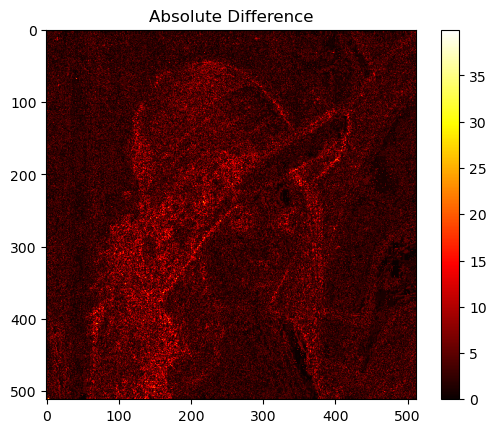

In [19]:
diff = np.abs(img.astype(np.float32) - reconstructed_img.astype(np.float32))

mae = np.mean(diff)
max_diff = np.max(diff)

print(f"Mean Absolute Error (MAE): {mae:.4f}")
print(f"Max Difference: {max_diff:.4f}")

plt.imshow(diff, cmap='hot')
plt.colorbar()
plt.title("Absolute Difference")
plt.show()